In [ ]:
"""Raw Binance data exploration — BTCUSDT"""

import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

DATA_DIR = Path("../data/raw/binance/BTCUSDT")
SAMPLE_EVERY = 10  # load every Nth file (1 = all, 10 = 10% sample)

files = sorted(DATA_DIR.glob("*.parquet"))
sample_files = files[::SAMPLE_EVERY]
df = pd.concat([pd.read_parquet(f) for f in sample_files], ignore_index=True)
print(f"Loaded {len(sample_files)}/{len(files)} files (every {SAMPLE_EVERY}th), {len(df):,} rows")
print(f"Time span: {pd.to_datetime(df.recv_ts.min(), unit='ms')} — {pd.to_datetime(df.recv_ts.max(), unit='ms')}")
df.head(3)

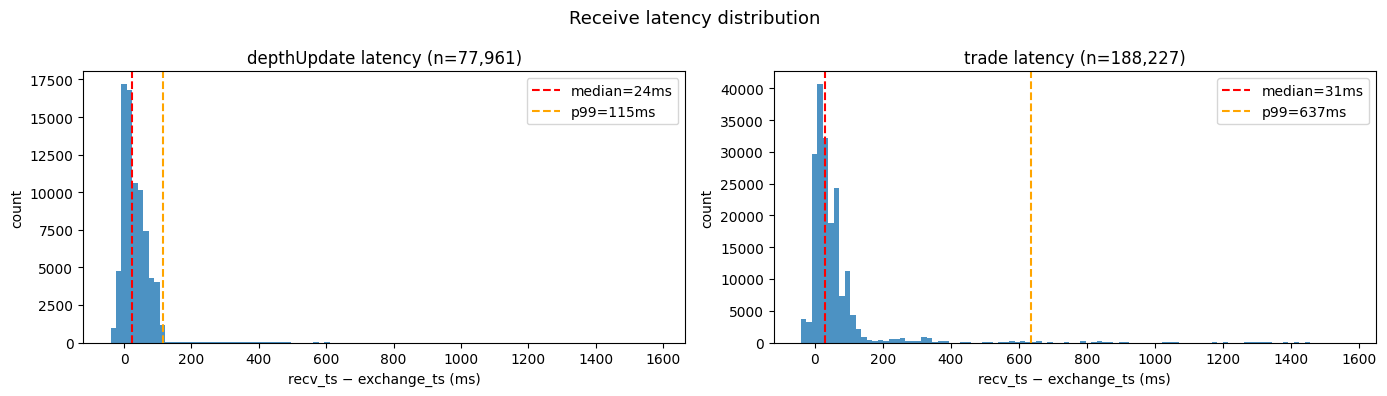

In [34]:
# --- 1. Receive latency (recv_ts - exchange_ts) ---

df["latency_ms"] = df["recv_ts"] - df["exchange_ts"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, etype in zip(axes, ["depthUpdate", "trade"]):
    lat = df.loc[df.event_type == etype, "latency_ms"]
    ax.hist(lat, bins=100, edgecolor="none", alpha=0.8)
    ax.set_title(f"{etype} latency (n={len(lat):,})")
    ax.set_xlabel("recv_ts − exchange_ts (ms)")
    ax.set_ylabel("count")
    ax.axvline(lat.median(), color="red", ls="--", label=f"median={lat.median():.0f}ms")
    ax.axvline(lat.quantile(0.99), color="orange", ls="--", label=f"p99={lat.quantile(0.99):.0f}ms")
    ax.legend()

fig.suptitle("Receive latency distribution", fontsize=13)
fig.tight_layout()
plt.show()

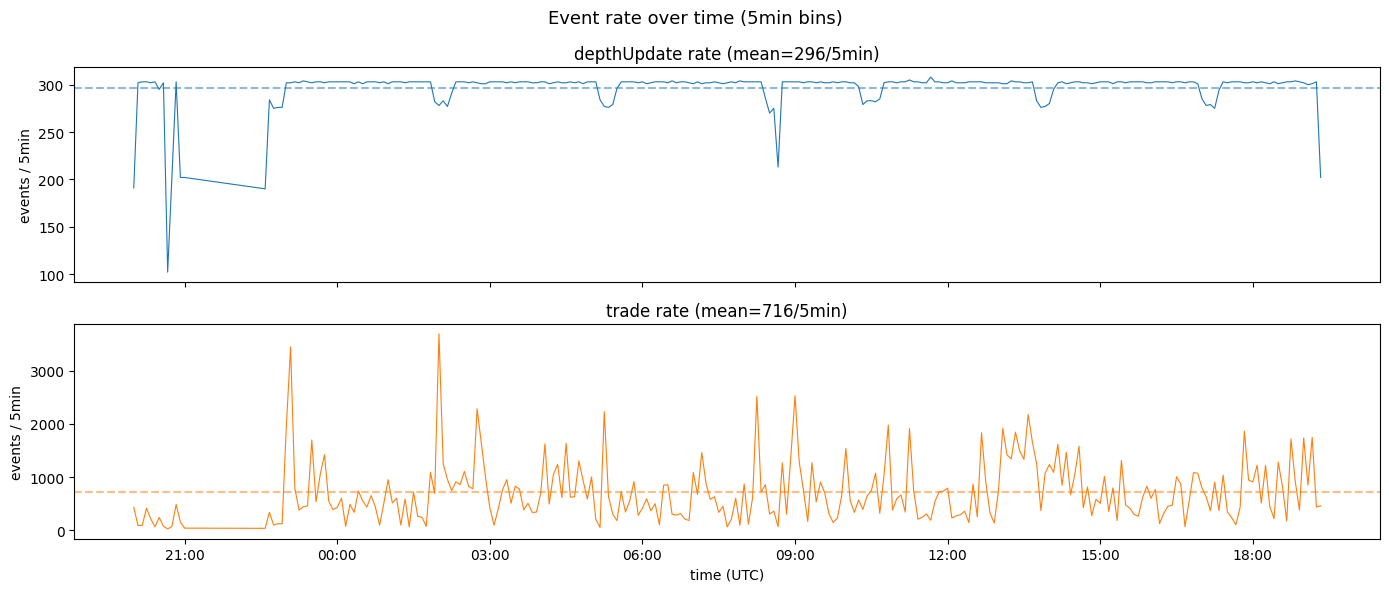

In [44]:
# --- 2. Event rate over time ---

RATE_WINDOW = "5min"

df["datetime"] = pd.to_datetime(df["recv_ts"], unit="ms")
df["bucket"] = df["datetime"].dt.floor(RATE_WINDOW)

event_rate = df.groupby(["bucket", "event_type"]).size().unstack(fill_value=0)

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

for ax, col, color in zip(axes, ["depthUpdate", "trade"], ["tab:blue", "tab:orange"]):
    ax.plot(event_rate.index, event_rate[col], color=color, linewidth=0.8)
    ax.set_ylabel(f"events / {RATE_WINDOW}")
    ax.set_title(f"{col} rate (mean={event_rate[col].mean():.0f}/{RATE_WINDOW})")
    ax.axhline(event_rate[col].mean(), color=color, ls="--", alpha=0.5)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
axes[-1].set_xlabel("time (UTC)")
fig.suptitle(f"Event rate over time ({RATE_WINDOW} bins)", fontsize=13)
fig.tight_layout()
plt.show()

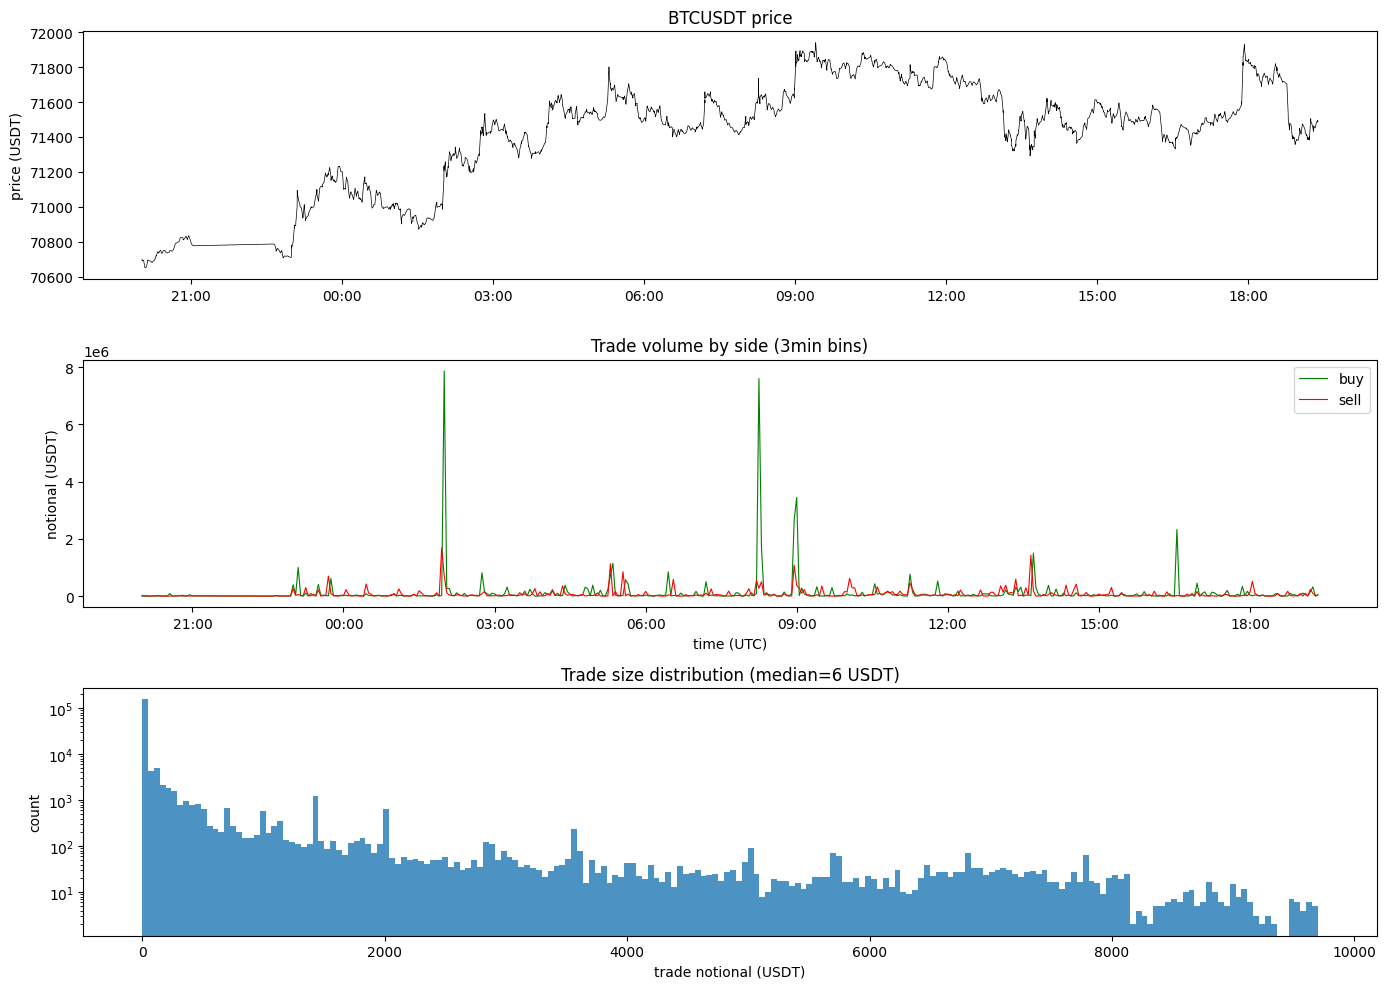

In [53]:
# --- 3. Trade volume and price ---

VOLUME_WINDOW = "3min"

trades = df[df.event_type == "trade"].copy()
parsed = trades["payload_json"].apply(json.loads)
trades["price"] = parsed.apply(lambda x: float(x["p"]))
trades["qty"] = parsed.apply(lambda x: float(x["q"]))
trades["side"] = np.where(parsed.apply(lambda x: x["m"]), "sell", "buy")
trades["notional"] = trades["price"] * trades["qty"]

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Price
ax = axes[0]
ax.plot(trades["datetime"], trades["price"], linewidth=0.5, color="black")
ax.set_ylabel("price (USDT)")
ax.set_title("BTCUSDT price")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

# Volume by side
trades["bucket"] = trades["datetime"].dt.floor(VOLUME_WINDOW)
vol_by_side = trades.groupby(["bucket", "side"])["notional"].sum().unstack(fill_value=0)
ax = axes[1]
if "buy" in vol_by_side:
    ax.plot(vol_by_side.index, vol_by_side["buy"], color="green", linewidth=0.8, label="buy")
if "sell" in vol_by_side:
    ax.plot(vol_by_side.index, vol_by_side["sell"], color="red", linewidth=0.8, label="sell")
# ax.set_yscale("log")
ax.set_ylabel("notional (USDT)")
ax.set_title(f"Trade volume by side ({VOLUME_WINDOW} bins)")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.set_xlabel("time (UTC)")

# Trade size distribution (log scale)
ax = axes[2]
ax.hist(trades["notional"], bins=200, edgecolor="none", alpha=0.8,
        range=(0, trades["notional"].quantile(0.99)))
ax.set_yscale("log")
ax.set_xlabel("trade notional (USDT)")
ax.set_ylabel("count")
ax.set_title(f"Trade size distribution (median={trades['notional'].median():.0f} USDT)")

fig.tight_layout()
plt.show()

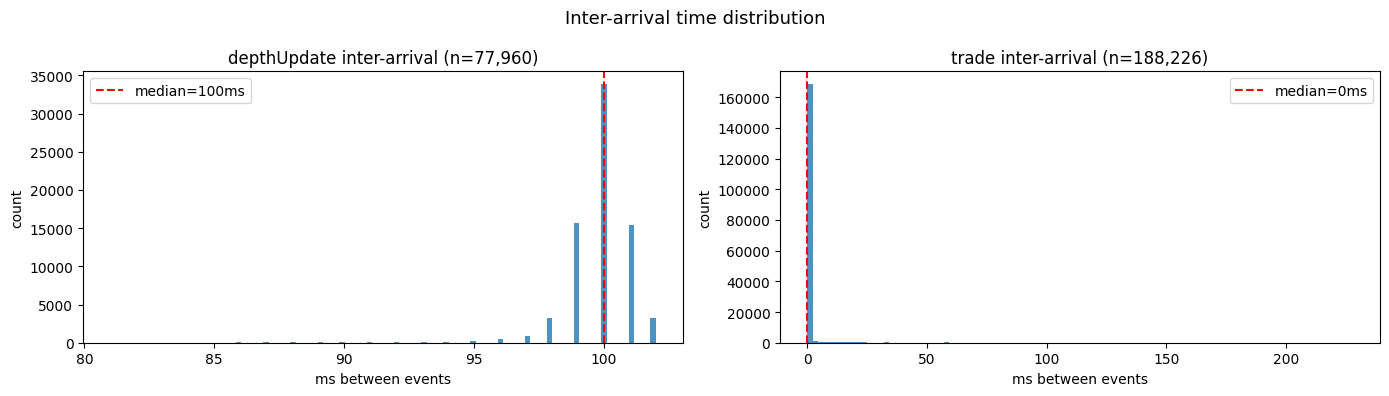

In [56]:
# --- 4. Inter-arrival times ---

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, etype in zip(axes, ["depthUpdate", "trade"]):
    subset = df[df.event_type == etype].sort_values("recv_ts")
    iat = subset["recv_ts"].diff().dropna()
    ax.hist(iat, bins=100, edgecolor="none", alpha=0.8, range=(iat.quantile(0.01), iat.quantile(0.95)))
    ax.set_title(f"{etype} inter-arrival (n={len(iat):,})")
    ax.set_xlabel("ms between events")
    ax.set_ylabel("count")
    ax.axvline(iat.median(), color="red", ls="--", label=f"median={iat.median():.0f}ms")
    ax.legend()

fig.suptitle("Inter-arrival time distribution", fontsize=13)
fig.tight_layout()
plt.show()

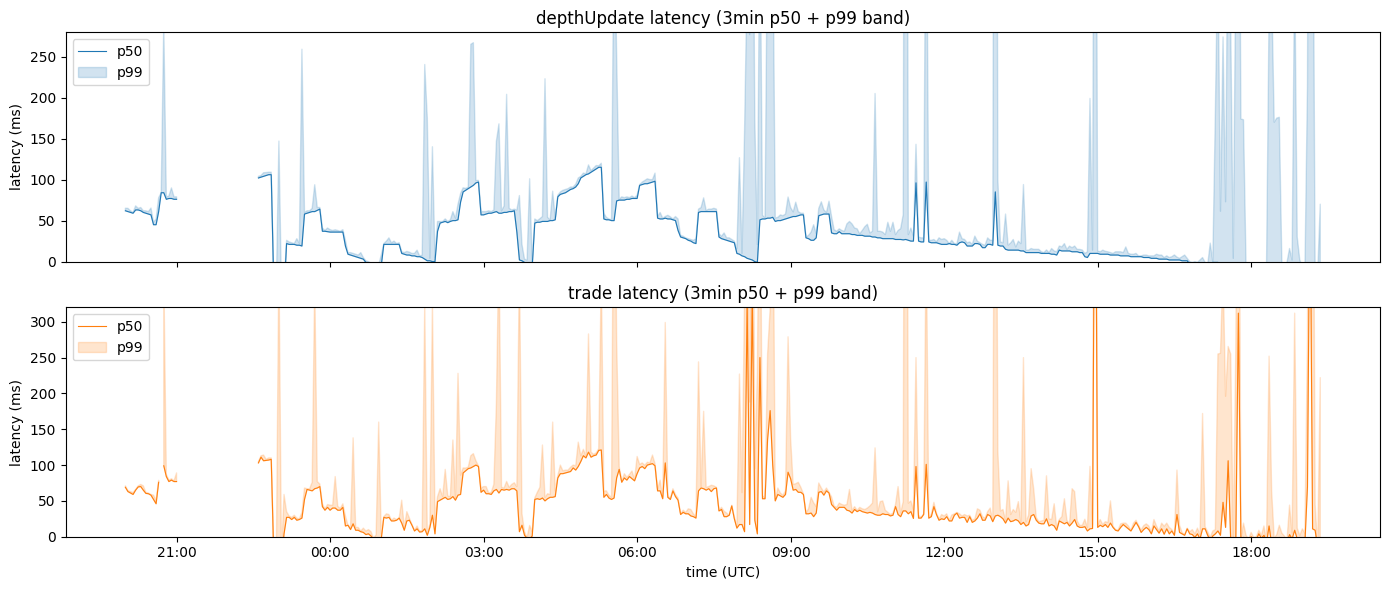

In [60]:
# --- 5. Latency over time (detect network instability) ---

LATENCY_WINDOW = "3min"

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

for ax, (etype, color) in zip(axes, [("depthUpdate", "tab:blue"), ("trade", "tab:orange")]):
    subset = df[df.event_type == etype]
    grouped = subset.set_index("datetime")["latency_ms"].resample(LATENCY_WINDOW)
    p50 = grouped.median()
    p99 = grouped.quantile(0.99)
    ax.plot(p50.index, p50, color=color, linewidth=0.8, label="p50")
    ax.fill_between(p99.index, p50, p99, color=color, alpha=0.2, label="p99")
    ax.set_ylim(0, p99.quantile(0.95))
    ax.set_ylabel("latency (ms)")
    ax.set_title(f"{etype} latency ({LATENCY_WINDOW} p50 + p99 band)")
    ax.legend()

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
axes[-1].set_xlabel("time (UTC)")
fig.tight_layout()
plt.show()

Continuous files loaded: 7749
Total depth updates: 780,928
Sequence gaps: 6
Stale events: 0

Gap locations (recv_ts):
  2026-03-14 20:33:26.359000  U=90132038916
  2026-03-14 20:44:22.698000  U=90132171814
  2026-03-14 20:50:26.890000  U=90132300043
  2026-03-14 20:59:43.890000  U=90132407846
  2026-03-14 22:38:09.520000  U=90133723850
  2026-03-15 08:44:08.063000  U=90148491833


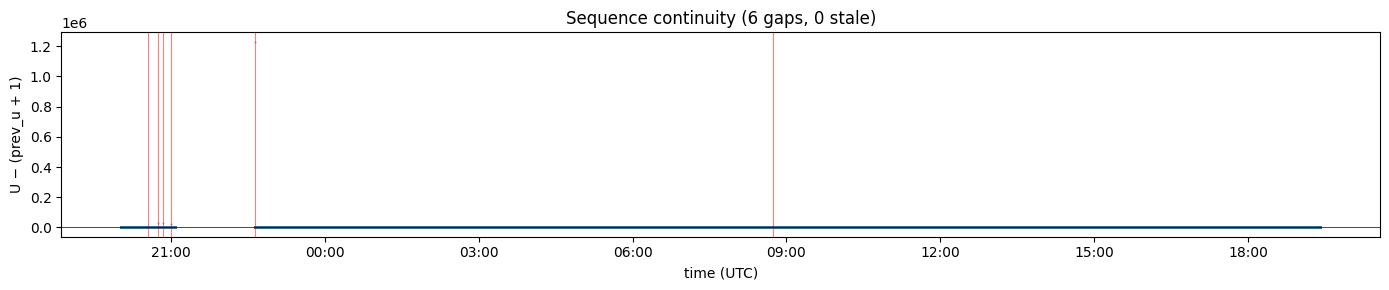

In [77]:
# --- 6. Depth update sequence gaps ---
# Emulate ReplayEngine's stateful sequence validation.
# Events are processed in parquet row order (no re-sorting).

continuous_files = files
depth_df = pd.concat([pd.read_parquet(f) for f in continuous_files], ignore_index=True)
depth = depth_df[depth_df.event_type == "depthUpdate"].copy()
parsed = depth["payload_json"].apply(json.loads)
depth["U"] = parsed.apply(lambda x: x["U"])
depth["u"] = parsed.apply(lambda x: x["u"])
depth["datetime"] = pd.to_datetime(depth["recv_ts"], unit="ms")
depth = depth.reset_index(drop=True)

# Stateful scan matching ReplayEngine logic
last_uid = None
labels = []
for _, row in depth.iterrows():
    if last_uid is None:
        last_uid = row["u"]
        labels.append("first")
    elif row["u"] < last_uid:
        labels.append("stale")
    elif row["U"] > last_uid + 1:
        labels.append("gap")
        last_uid = None
    else:
        last_uid = row["u"]
        labels.append("ok")

depth["status"] = labels
gaps = depth[depth.status == "gap"]
stale = depth[depth.status == "stale"]

print(f"Continuous files loaded: {len(continuous_files)}")
print(f"Total depth updates: {len(depth):,}")
print(f"Sequence gaps: {len(gaps)}")
print(f"Stale events: {len(stale)}")

if len(gaps) > 0:
    print(f"\nGap locations (recv_ts):")
    for _, g in gaps.iterrows():
        print(f"  {g.datetime}  U={g.U}")

fig, ax = plt.subplots(figsize=(14, 3))
depth["delta"] = depth["U"] - depth["u"].shift(1).fillna(depth["U"].iloc[0]) - 1
ax.plot(depth["datetime"], depth["delta"], ".", markersize=1, alpha=0.5)
for _, g in gaps.iterrows():
    ax.axvline(g.datetime, color="red", alpha=0.5, linewidth=0.8)
ax.set_ylabel("U − (prev_u + 1)")
ax.set_title(f"Sequence continuity ({len(gaps)} gaps, {len(stale)} stale)")
ax.axhline(0, color="black", linewidth=0.5)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.set_xlabel("time (UTC)")
fig.tight_layout()
plt.show()

del depth_df

In [78]:
# --- 7. Summary stats ---

print("=== Dataset summary ===")
print(f"SAMPLE_EVERY: {SAMPLE_EVERY} (setting)")
print(f"Time span: {df.datetime.min()} — {df.datetime.max()}")
print(f"Duration: {df.datetime.max() - df.datetime.min()}")
print(f"Total events: {len(df):,}")
print()
print("Event counts:")
print(df.event_type.value_counts().to_string())
print()
print("Latency (ms):")
print(df.groupby("event_type")["latency_ms"].describe().round(1).to_string())
print()
print(f"Trades: {len(trades):,}")
print(f"  Total notional: ${trades.notional.sum():,.0f}")
print(f"  Mean trade size: ${trades.notional.mean():,.0f}")
print(f"  Median trade size: ${trades.notional.median():,.0f}")
print(f"  Buy/sell ratio: {(trades.side=='buy').mean():.1%} / {(trades.side=='sell').mean():.1%}")

=== Dataset summary ===
SAMPLE_EVERY: 10 (setting)
Time span: 2026-03-14 20:02:00.077000 — 2026-03-15 19:22:53.897000
Duration: 0 days 23:20:53.820000
Total events: 266,188

Event counts:
event_type
trade          188227
depthUpdate     77961

Latency (ms):
                count  mean    std   min   25%   50%   75%     max
event_type                                                        
depthUpdate   77961.0  33.2   48.6 -40.0   6.0  24.0  54.0  1585.0
trade        188227.0  57.1  113.9 -40.0  13.0  31.0  64.0  1568.0

Trades: 188,227
  Total notional: $89,497,695
  Mean trade size: $475
  Median trade size: $6
  Buy/sell ratio: 47.6% / 52.4%
